<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/Copy_omds_modc_week6_banerjee_jayeeta_data2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score,recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay,confusion_matrix,classification_report,RocCurveDisplay
import matplotlib.pyplot as plt
from scipy.stats import randint

In [ ]:
datasource= "https://archive.ics.uci.edu/static/public/383/data.csv"

df_CivicalCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_CivicalCancer.sample(10, random_state=42) #printing random sample of 10 rows

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
713,16,1.0,16.0,1.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
604,23,3.0,17.0,2.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
120,33,1.0,16.0,4.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
208,27,4.0,16.0,1.0,0.0,0.0,0.000,1.0,0.67,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
380,18,3.0,15.0,1.0,1.0,2.0,0.003,1.0,0.58,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
813,20,1.0,17.0,NaN,0.0,0.0,0.000,1.0,1.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
575,17,2.0,15.0,1.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
266,21,2.0,19.0,1.0,0.0,0.0,0.000,1.0,1.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
557,27,2.0,17.0,3.0,0.0,0.0,0.000,1.0,0.25,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
822,36,3.0,20.0,2.0,0.0,0.0,0.000,1.0,6.00,0.0,...,16.0,16.0,1,0,1,1,0,0,0,0


In [ ]:
df_CivicalCancer = df_CivicalCancer.drop(columns=[
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis",
    "STDs:cervical condylomatosis",
    "STDs:AIDS"
])
binary_cols = ["Smokes (packs/year)", "IUD (years)", "STDs (number)", "Hormonal Contraceptives (years)"]
df_CivicalCancer[binary_cols] = df_CivicalCancer[binary_cols].fillna(0)

#df_CivicalCancer[num_cols] = df_CivicalCancer[num_cols].fillna(df_CivicalCancer[num_cols].median())
df_CivicalCancer["Number of sexual partners"] = df_CivicalCancer["Number of sexual partners"].fillna(df_CivicalCancer["Number of sexual partners"].median())
df_CivicalCancer["Num of pregnancies"] = df_CivicalCancer["Num of pregnancies"].fillna(df_CivicalCancer["Num of pregnancies"].median())
df_CivicalCancer["First sexual intercourse"] = df_CivicalCancer["First sexual intercourse"].fillna(df_CivicalCancer["First sexual intercourse"].median())
df_CivicalCancer["Smokes (packs/year)"] = df_CivicalCancer["Smokes (packs/year)"].fillna(df_CivicalCancer["Smokes (packs/year)"].median())
df_CivicalCancer["IUD (years)"] = df_CivicalCancer["IUD (years)"].fillna(df_CivicalCancer["IUD (years)"].median())
df_CivicalCancer["STDs (number)"] = df_CivicalCancer["STDs (number)"].fillna(df_CivicalCancer["STDs (number)"].median())
df_CivicalCancer["STDs: Number of diagnosis"] = df_CivicalCancer["STDs: Number of diagnosis"].fillna(df_CivicalCancer["STDs: Number of diagnosis"].median())

df_CivicalCancer["Hormonal Contraceptives (years)"] = df_CivicalCancer["Hormonal Contraceptives (years)"].fillna(df_CivicalCancer["Hormonal Contraceptives (years)"].median())
df_CivicalCancer["STDs:condylomatosis"] = df_CivicalCancer["STDs:condylomatosis"].fillna(df_CivicalCancer["STDs:condylomatosis"].median())
#df_CivicalCancer["STDs:cervical condylomatosis"] = df_CivicalCancer["STDs:cervical condylomatosis"].fillna(df_CivicalCancer["STDs:cervical condylomatosis"].median())
df_CivicalCancer["STDs:vulvo-perineal condylomatosis"] = df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].fillna(df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].median())
df_CivicalCancer["STDs:syphilis"] = df_CivicalCancer["STDs:syphilis"].fillna(df_CivicalCancer["STDs:syphilis"].median())
df_CivicalCancer["STDs:pelvic inflammatory disease"] = df_CivicalCancer["STDs:pelvic inflammatory disease"].fillna(df_CivicalCancer["STDs:pelvic inflammatory disease"].median())
df_CivicalCancer["STDs:genital herpes"] = df_CivicalCancer["STDs:genital herpes"].fillna(df_CivicalCancer["STDs:genital herpes"].median())
df_CivicalCancer["STDs:molluscum contagiosum"] = df_CivicalCancer["STDs:molluscum contagiosum"].fillna(df_CivicalCancer["STDs:molluscum contagiosum"].median())
#df_CivicalCancer["STDs:AIDS"] = df_CivicalCancer["STDs:AIDS"].fillna(df_CivicalCancer["STDs:AIDS"].median())
df_CivicalCancer["STDs:Hepatitis B"] = df_CivicalCancer["STDs:Hepatitis B"].fillna(df_CivicalCancer["STDs:Hepatitis B"].median())
df_CivicalCancer["STDs:HPV"] = df_CivicalCancer["STDs:HPV"].fillna(df_CivicalCancer["STDs:HPV"].median())

df_CivicalCancer["Dx:HPV"] = df_CivicalCancer["Dx:HPV"].fillna(df_CivicalCancer["Dx:HPV"].mode())
df_CivicalCancer["Dx:CIN"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:CIN"].mode())
df_CivicalCancer["Dx:Cancer"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:Cancer"].mode())

df_CivicalCancer_nw= df_CivicalCancer[["Age","Number of sexual partners","First sexual intercourse",
                 "Num of pregnancies","Smokes (packs/year)","Hormonal Contraceptives (years)","IUD (years)","STDs (number)","STDs: Number of diagnosis",
                                    "STDs:condylomatosis", "STDs:vulvo-perineal condylomatosis",
                                    "STDs:syphilis","STDs:pelvic inflammatory disease","STDs:genital herpes",
                                    "STDs:molluscum contagiosum","STDs:Hepatitis B","STDs:HPV", "Biopsy"]]



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
#Target and Features
X= df_CivicalCancer_nw.drop(["Biopsy"], axis=1)
y= df_CivicalCancer_nw["Biopsy"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

Decision Tree Accuracy: 0.9488372093023256


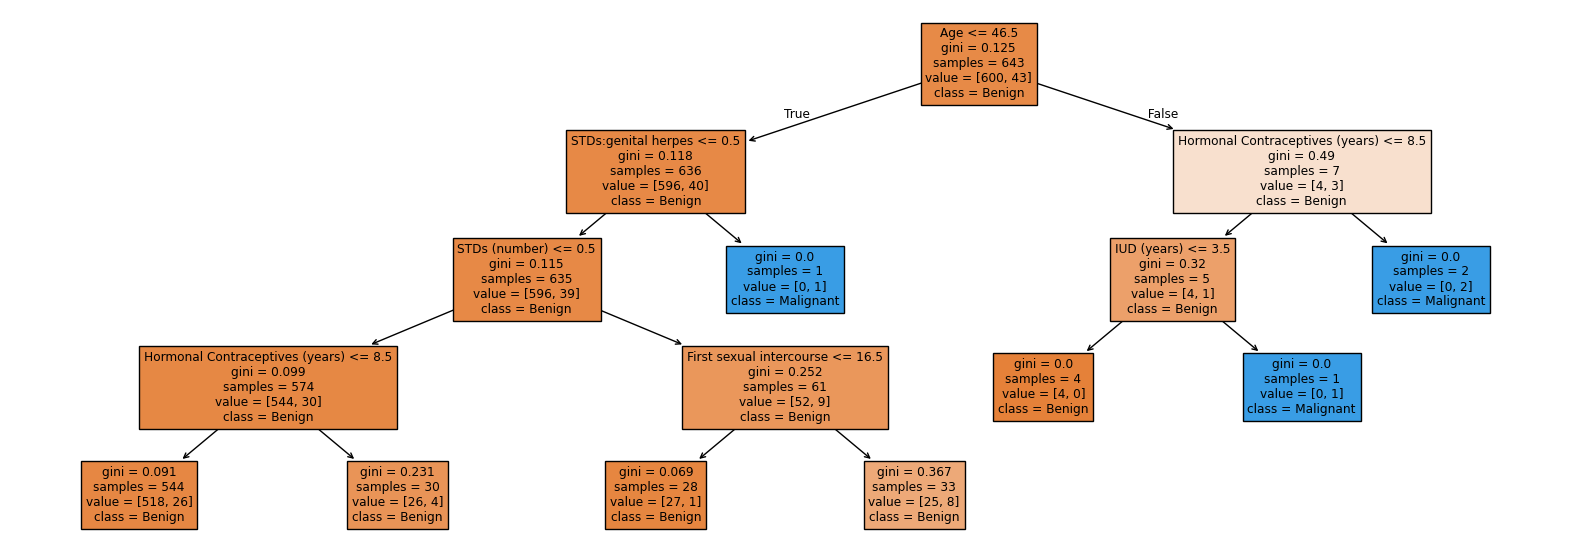

In [ ]:
#Training a Decision Tree
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
tree_accuracy = accuracy_score(y_test, y_pred_tree)
print("Decision Tree Accuracy:", tree_accuracy)

#Visualize
plt.figure(figsize=(20,7))
plot_tree(tree, feature_names=X.columns, class_names=["Benign","Malignant"], filled=True)
plt.show()

                            Feature  Importance
5   Hormonal Contraceptives (years)    0.230196
0                               Age    0.189899
13              STDs:genital herpes    0.180402
6                       IUD (years)    0.164086
2          First sexual intercourse    0.132753
7                     STDs (number)    0.102664
4               Smokes (packs/year)    0.000000
1         Number of sexual partners    0.000000
3                Num of pregnancies    0.000000
8         STDs: Number of diagnosis    0.000000


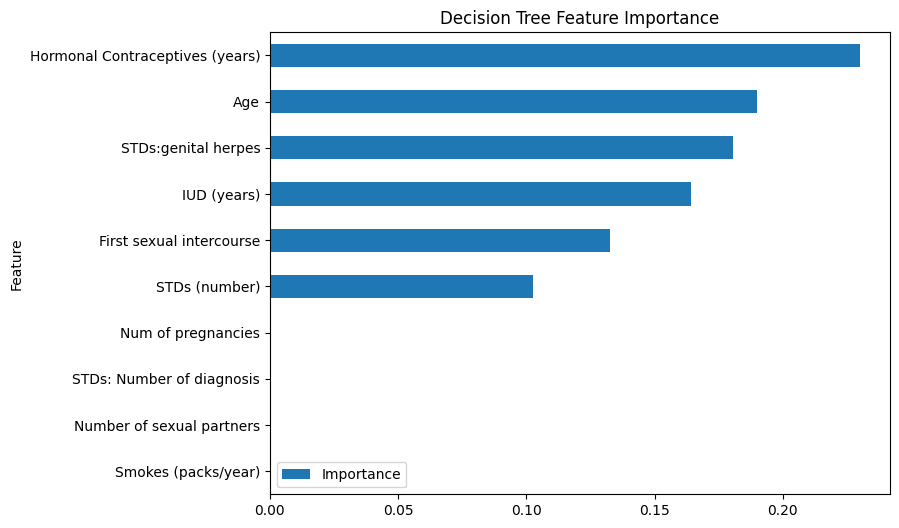

In [ ]:
#Feature Importance in Decision Trees
importance_df = pd.DataFrame({"Feature": X.columns, "Importance": tree.feature_importances_})
importance_df = importance_df.sort_values("Importance", ascending=False)
print(importance_df.head(10))
#visualize
importance_df.head(10).sort_values("Importance").plot(x="Feature", y="Importance", kind="barh", figsize=(8,6))
plt.title("Decision Tree Feature Importance")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy Score:  0.9441860465116279

Confusion Matrix: 
 [[203   0]
 [ 12   0]]

Classification Report: 

               precision    recall  f1-score   support

           0       0.94      1.00      0.97       203
           1       0.00      0.00      0.00        12

    accuracy                           0.94       215
   macro avg       0.47      0.50      0.49       215
weighted avg       0.89      0.94      0.92       215

------------------------------------------------------------------------------------------


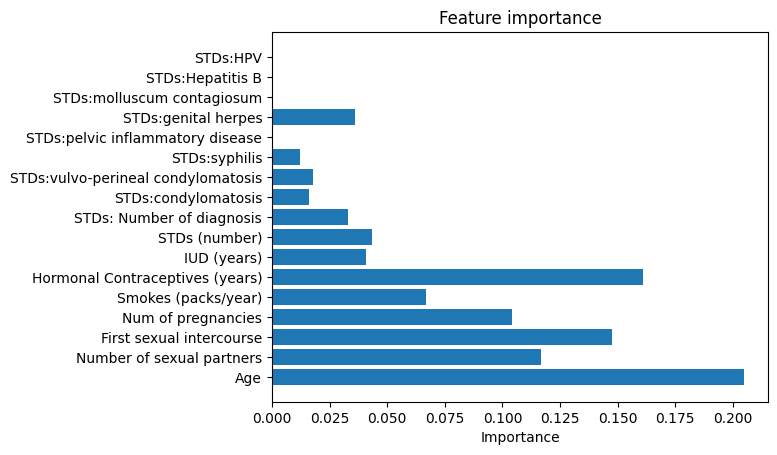

<Figure size 640x480 with 0 Axes>

In [ ]:
#Training a Random Forest

rf=RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train,y_train)

#Prediction
y_pred_rf=rf.predict(X_test)

#evaluations
accuracy = accuracy_score(y_test, y_pred_rf)
cm = confusion_matrix(y_test, y_pred_rf)
cr = classification_report(y_test, y_pred_rf)
print("Accuracy Score: ", accuracy)
print("\nConfusion Matrix: \n", cm)
print("\nClassification Report: \n\n", cr)
print("------------------------------------------------------------------------------------------")

#Feature importance
importance_rf = rf.feature_importances_
#plot
plt.barh(X.columns, importance_rf)
plt.xlabel("Importance")
plt.title("Feature importance")
plt.show()
plt.tight_layout()

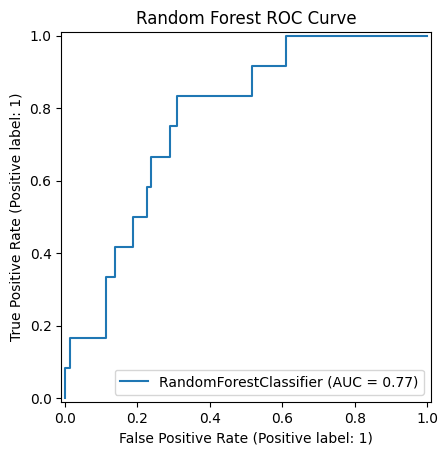

In [ ]:
#ROC curve
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest ROC Curve")
plt.show()


In [ ]:
#Tune Hyperparameter RandomizedSearchCV
rf=RandomForestClassifier(random_state=42)
param_dist = {"n_estimators": randint(50, 300),
              "max_depth": randint(2,15),
              "min_samples_split": randint(2,10),
              "min_samples_leaf": randint(1,5)}

search = RandomizedSearchCV(
    rf,
    param_distributions = param_dist,
    n_iter=20,
    cv=5,
    random_state=42,
    n_jobs=-1)
search.fit(X_train, y_train)
best_model = search.best_estimator_
best_param = search.best_params_
print("Best Model: ", best_model)
print("\nBest Parameters: ", best_param)


Best Model:  RandomForestClassifier(max_depth=13, n_estimators=253, random_state=42)

Best Parameters:  {'max_depth': 13, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 253}


In [ ]:
#Tune Hyperparameter GridSearchCV
param_grid = {'n_estimators': [100,200,500],
              'max_depth': [3,5,10,None],
              'min_samples_split': [2,5,10],
              'min_samples_leaf': [1,2,4]}
grid =  GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_param = grid.best_params_
print("Best Model: ", best_model)
print("\nBest Parameters: ", best_param)


Best Model:  RandomForestClassifier(random_state=42)

Best Parameters:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


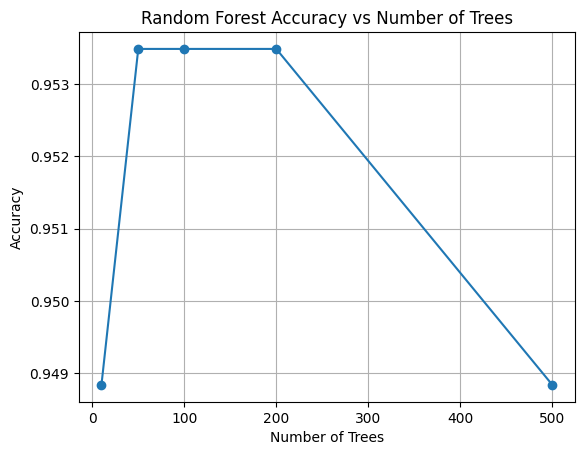

In [ ]:
trees = [10, 50, 100, 200, 500]
accuracies = []

for n in trees:

    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    accuracies.append(
        accuracy_score(y_test, y_pred)
    )

plt.plot(trees, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.grid(True)
plt.show()